# Evaluation: Attacks

## Setup

In [1]:
# Hack for import from another directory
from pathlib import Path
import sys

poc_path = str(Path().resolve().parent)
if poc_path not in sys.path:
    sys.path.append(poc_path)

In [2]:
from collections.abc import Callable
from itertools import product
from pathlib import Path
from pickle import dump, load
from random import Random
from statistics import mean, median, stdev
from typing import Any, Iterable

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from compressors.interface import *
from crime_automata import filler, utils
from crime_automata.deflate import automata, params
from crime_automata.deflate.collisions import DeflateInstanceSet
from crime_automata.deflate.gadgets import *
from crime_automata.dictionary import SimpleDictionaryDedup
from crime_automata.gadgets import PlaceholderGadget
from crime_automata.randbytes import RandBytes
from crime_automata.strategies.models import (
    CRIMESlideModel,
    CRIMECascadeModel,
)
from crime_automata.strategies.oracle import (
    TestCompressionLengthOracle,
    Placeholder,
    ValidityCheckOracle,
)
from crime_automata.strategies.matchbuilder import (
    DefaultMatchBuilder,
)
from crime_automata.strategies.searcher import (
    Searcher,
    SimpleBatchSearcher,
    SimpleCascadeSearcher,
)

from rupture import RuptureSearcher, Target

In [3]:
TEST_MODE = False
ATTACK_RNG_SEED = b"attack_test" if TEST_MODE else b"attack"
EVAL_RNG_SEED = b"eval_test" if TEST_MODE else b"eval"
DEMO_RNG = Random(b"demo")

NUM_EVALS = 1000

RESULTS_DIR = "results_attack/"

In [4]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

In [5]:
def save_results(results: list[list], filename: str) -> None:
    with open(Path(RESULTS_DIR, filename), "wb") as f:
        dump(results, f)


def load_results(filename: str) -> list[list]:
    with open(Path(RESULTS_DIR, filename), "rb") as f:
        return load(f)

In [6]:
def evaluate(
    experiment: Callable[[Random, Random], tuple[int, ...]],
    n: int,
    attack_rng: Random | None = None,
    eval_rng: Random | None = None,
    salt: bytes = b"",
    progressbar: bool = True,
    filename: str | None = None,
) -> list[list]:
    if attack_rng is None:
        attack_rng = Random(ATTACK_RNG_SEED + salt)
    if eval_rng is None:
        eval_rng = Random(EVAL_RNG_SEED + salt)
    results = list(
        zip(
            *[
                experiment(attack_rng, eval_rng)
                for _ in tqdm(range(n), disable=not progressbar)
            ]
        )
    )
    if filename is not None:
        save_results(results, filename=filename)
    return results

In [7]:
def unif_noise_len_closure(lb: int, ub: int) -> int:
    return lambda rng: rng.randint(lb, ub)


[unif_noise_len_closure(0, 5)(DEMO_RNG) for _ in range(10)]

[5, 3, 2, 4, 4, 0, 0, 0, 5, 4]

In [8]:
def report_stats(result: Iterable[int]) -> dict[str, int | float]:
    # Note that Bessel's correction is applied for the sample standard deviation
    if len(result) == 0:
        return {}
    return {
        "min": min(result),
        "max": max(result),
        "mean": mean(result),
        "stdev": stdev(result) if len(result) > 1 else None,
    }

In [9]:
def analyze_results(results: tuple, print_failures: bool = False):
    print(
        f"n: {len(results[0])}, #successes: {sum(results[0])}, max #queries: {max(results[1])}, max query length: {max(results[2])}"
    )
    print("stats on #queries: ", report_stats(results[1]))
    print(
        "stats on #queries in successful experiments: ",
        report_stats([num for i, num in enumerate(results[1]) if results[0][i]]),
    )
    if print_failures and False in results[0]:
        print("[failed experiments] #queries, max query length, guess, secret")
        for i, b in enumerate(results[0]):
            if not b:
                print(
                    results[1][i], results[2][i], results[3][i], results[4][i], sep="\t"
                )

In [10]:
def plot_hist(
    recovered: list[bool],
    num_queries: list[int],
    xlim: tuple[int, int] | None = None,
    ylim: int | None = None,
    bin_width: int = 5,
    kwargs: dict | None = None,
    filename: str | None = None,
):
    if kwargs is None:
        kwargs = dict()
    fig, ax = plt.subplots()
    fig.set_size_inches(6, 3)

    n = len(recovered)
    assert n == len(num_queries)
    x_succ = [num_queries[i] for i in range(n) if recovered[i]]
    x_fail = [num_queries[i] for i in range(n) if not recovered[i]]
    mean_queries = mean(num_queries)

    if xlim is not None:
        ax.set_xlim(left=xlim[0], right=xlim[1])
    if ylim is not None:
        ax.set_ylim(top=ylim)

    x_l, x_r = ax.get_xlim()
    bins = range(int(x_l), int(x_r) + bin_width, bin_width)

    ax.hist(
        [x_succ, x_fail],
        histtype="bar",
        stacked=True,
        bins=bins,
        #color=["#59a6c4", "#ad1325"],
        color=["#4ea4d2", "#a30013"],
        label=["correct", "incorrect"],
        **kwargs,
    )
    ax.tick_params(axis="both", which="major", labelsize=16)
    ax.axvline(mean_queries, linestyle="dashed", color="#d8b365", linewidth=2)
    _, y_t = ax.get_ylim()
    ax.text(
        mean_queries + (x_r - x_l) * 0.05,
        y_t * 0.85,
        s=f"mean={mean_queries:.1f}",
        fontsize="xx-large",
    )

    if filename is not None:
        fig.savefig(Path(RESULTS_DIR, filename), bbox_inches="tight")

    return fig, ax

In [11]:
# `[k1 filler bytes][prefix][secret][k2 filler bytes][query][k3 filler bytes][optional noise]`
def attack_expt_closure(
    searcher: Searcher,
    compress: Callable[[Any], bytes],
    filler_sizes: tuple[int, int, int] = (500, 500, 500),
    filler_charset: bytes = utils.ASCII_PRINTABLE_BYTES,
    prefix_size: int = 8,
    prefix_charset: bytes = utils.ALPHANUMERIC_BYTES,
    secret_size: int = 32,
    secret_charset: bytes = utils.ALPHANUMERIC_BYTES,
    noise_size: int = 20,
    noise_charset: bytes = utils.ALL_BYTES,
    max_queries: int | None = 2000,
    block_pad_size: int = 0,
) -> Callable[[Random, Random], tuple[int, ...]]:

    def attack_expt(
        attack_rng: Random, eval_rng: Random
    ) -> tuple[bool, int, int, bytes | None, bytes]:
        fillers = [
            RandBytes(filler_charset, eval_rng).randbytes(filler_sizes[i])
            for i in range(3)
        ]
        prefix = RandBytes(prefix_charset, eval_rng).randbytes(prefix_size)
        secret = RandBytes(secret_charset, eval_rng).randbytes(secret_size)
        template = [
            fillers[0],
            prefix,
            Placeholder.SECRET,
            Placeholder.NOISE,
            fillers[1],
            Placeholder.QUERY,
            fillers[2],
        ]

        pad_len_func = lambda l, _: block_pad_size - l % block_pad_size
        oracle = TestCompressionLengthOracle(
            template=template,
            compress=compress,
            secret=secret,
            noise_lens=[unif_noise_len_closure(0, noise_size)],
            noise_charset=noise_charset,
            pad_len=pad_len_func if block_pad_size > 0 else None,
            rng=eval_rng,
        )

        searcher.set_oracle(oracle)
        searcher.reset_stats()  # just in case
        searcher.set_max_queries(max_queries)
        searcher.flush()

        guess = searcher.recover(
            prefix=prefix, alphabet=secret_charset, length=secret_size, rng=attack_rng
        )

        return (
            guess == secret,
            searcher.num_queries,
            searcher.max_query_len,
            guess,
            secret,
        )

    return attack_expt

In [12]:
deflate_match_builder_default = DefaultMatchBuilder(
    TargetMatch,
    GeneralORTargetMatch,
    match_kwargs={"add_prefix": True},
    or_match_kwargs={"glue_length": 5},
)
telescoped_match_builder_default = DefaultMatchBuilder(
    TelescopedMatch, None, match_kwargs={"k": None}
)  # should choose k=7 automatically
random_telescoped_match_builder_default = DefaultMatchBuilder(
    RandomTelescopedMatch,
    None,
    match_kwargs={"k": None, "sep_len": 1, "distinct_seps": True},
)

In [13]:
zlib_inst_set_single = DeflateInstanceSet(
    colls=[[b"pr1", b"qPq", b"r0q", b"Pr1"]], hash_func=params.ZLIB_DEFAULT_HASH
)
zlib_inst_set_double = DeflateInstanceSet(
    colls=[[b"pr1Q", b"qPqQ", b"r0qQ", b"Pr1Q"]], hash_func=params.ZLIB_DEFAULT_HASH
)

## Main experiments

In [14]:
MATCH_NOISE_SIZE = 50
COLL_NOISE_SIZE = 100

### Batch search

In [15]:
BATCH_MAX_QUERIES = 250
BATCH_PAD_SIZE = 16

In [16]:
crime_slide_match_model = CRIMESlideModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(b"-" * 100),
        dict_1=SimpleDictionaryDedup(fine_grained=False),
        dict_2=SimpleDictionaryDedup(fine_grained=False),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(650, k=None, double=True),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)
batch_match_searcher = SimpleBatchSearcher(
    model=crime_slide_match_model,
    oracle=None,
    max_queries=None,
    threshold=110,
    max_cands=None,
    ormatch_comp_len=13,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_history=True,
)

In [17]:
results_batch_match = evaluate(
    attack_expt_closure(
        searcher=batch_match_searcher,
        secret_size=32,
        noise_size=MATCH_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=BATCH_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"batch_match_searcher",
    filename="batch_match_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [18]:
results_batch_match = load_results("batch_match_searcher.pickle")
analyze_results(results_batch_match, print_failures=False)

n: 1000, #successes: 1000, max #queries: 245, max query length: 2936
stats on #queries:  {'min': 206, 'max': 245, 'mean': 213.973, 'stdev': 4.187577677704237}
stats on #queries in successful experiments:  {'min': 206, 'max': 245, 'mean': 213.973, 'stdev': 4.187577677704237}


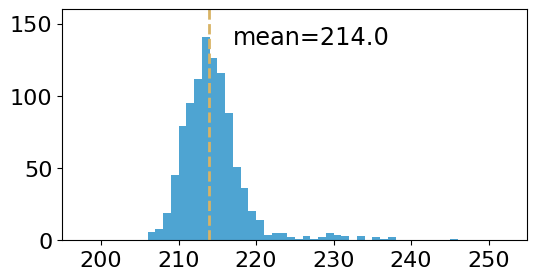

In [19]:
%matplotlib inline
fig, ax = plot_hist(results_batch_match[0], results_batch_match[1], xlim=(195, 255), ylim=160, bin_width=1, filename="batch_match_searcher.pdf")

In [20]:
results_batch_match_padded = evaluate(
    attack_expt_closure(
        searcher=batch_match_searcher,
        secret_size=32,
        noise_size=MATCH_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=BATCH_MAX_QUERIES,
        block_pad_size=BATCH_PAD_SIZE,
    ),
    n=NUM_EVALS,
    salt=b"batch_match_searcher_padded",
    filename="batch_match_searcher_padded.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [21]:
results_batch_match_padded = load_results("batch_match_searcher_padded.pickle")
analyze_results(results_batch_match_padded, print_failures=False)

n: 1000, #successes: 998, max #queries: 250, max query length: 2936
stats on #queries:  {'min': 203, 'max': 250, 'mean': 213.797, 'stdev': 4.038824470449676}
stats on #queries in successful experiments:  {'min': 203, 'max': 238, 'mean': 213.77054108216433, 'stdev': 3.8643568247280293}


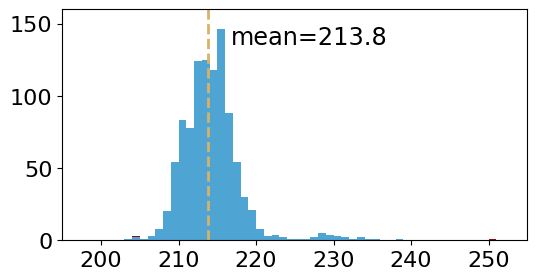

In [22]:
%matplotlib inline
fig, ax = plot_hist(results_batch_match_padded[0], results_batch_match_padded[1], xlim=(195, 255), ylim=160, bin_width=1, filename="batch_match_searcher_padded.pdf")

#### Collision

In [23]:
crime_slide_coll_model = CRIMESlideModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(),
        dict_1=SimpleDictionaryDedup(fine_grained=False),
        dict_2=SimpleDictionaryDedup(fine_grained=False),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        CollisionAmplify(
            max_len=2200,
            instance=zlib_inst_set_double,
            auto_expand=True,
            nop_gadget=None,
        ),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)
batch_coll_searcher = SimpleBatchSearcher(
    model=crime_slide_coll_model,
    oracle=None,
    max_queries=None,
    threshold=-210,
    max_cands=None,
    ormatch_comp_len=10,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_history=True,
)

In [24]:
results_batch_coll = evaluate(
    attack_expt_closure(
        searcher=batch_coll_searcher,
        secret_size=32,
        noise_size=COLL_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=BATCH_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"batch_coll_searcher",
    filename="batch_coll_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [25]:
results_batch_coll = load_results("batch_coll_searcher.pickle")
analyze_results(results_batch_coll, print_failures=False)

n: 1000, #successes: 997, max #queries: 250, max query length: 3749
stats on #queries:  {'min': 204, 'max': 250, 'mean': 214.882, 'stdev': 5.96268644401411}
stats on #queries in successful experiments:  {'min': 204, 'max': 249, 'mean': 214.7763289869609, 'stdev': 5.651093770883789}


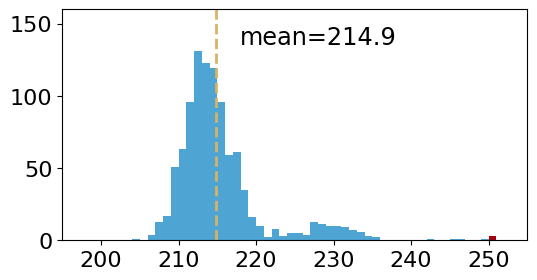

In [26]:
%matplotlib inline
fig, ax = plot_hist(results_batch_coll[0], results_batch_coll[1], bin_width=1, xlim=(195, 255), ylim=160, filename="batch_coll_searcher.pdf")

In [27]:
results_batch_coll_padded = evaluate(
    attack_expt_closure(
        searcher=batch_coll_searcher,
        secret_size=32,
        noise_size=COLL_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=BATCH_MAX_QUERIES,
        block_pad_size=BATCH_PAD_SIZE,
    ),
    n=NUM_EVALS,
    salt=b"batch_coll_searcher_padded",
    filename="batch_coll_searcher_padded.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [28]:
results_batch_coll_padded = load_results("batch_coll_searcher_padded.pickle")
analyze_results(results_batch_coll_padded, print_failures=False)

n: 1000, #successes: 993, max #queries: 250, max query length: 3749
stats on #queries:  {'min': 204, 'max': 250, 'mean': 215.006, 'stdev': 6.091064362249431}
stats on #queries in successful experiments:  {'min': 204, 'max': 248, 'mean': 214.7593152064451, 'stdev': 5.353574734120265}


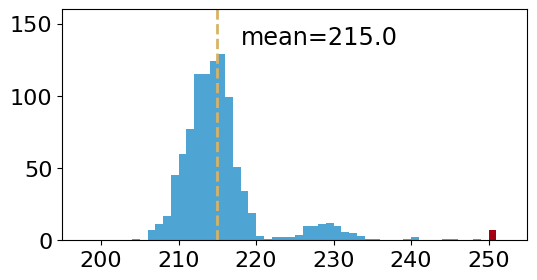

In [29]:
%matplotlib inline
fig, ax = plot_hist(results_batch_coll_padded[0], results_batch_coll_padded[1], bin_width=1, xlim=(195, 255), ylim=160, filename="batch_coll_searcher_padded.pdf")

### Cascade search

In [30]:
CASCADE_NOISE_SIZE = 100
CASCADE_MAX_QUERIES = 150
CASCADE_PAD_SIZE = 16
NUM_PLACEHOLDERS = 6

#### match chain

In [31]:
crime_cascade_match_model = CRIMECascadeModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(b"-" * 0),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(350, k=None, double=True),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(400, k=None, double=True),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(450, k=None, double=True),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(500, k=None, double=True),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(650, k=None, double=True),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(900, k=None, double=True),
    ],
    placeholder=[2 * i + 1 for i in range(NUM_PLACEHOLDERS)],
    match_builder=deflate_match_builder_default,
    do_validity_check=True,
    test_oracle=ValidityCheckOracle(
        template=[b"secret=", Placeholder.SECRET, b"&query=", Placeholder.QUERY],
        compress=ZlibMiniCompressor(6).compress,
    ),
    thresholds=None,
    max_retry=1,
    strict=False,
    collect_stats=True,
)

In [32]:
crime_cascade_match_model.stats = None
# determine thresholds empirically
threshold_rng = Random(ATTACK_RNG_SEED + b"cascade_match/threshold")
for _ in range(100):
    fake_updates = [[f"123456{i:03}".encode()] for i in range(NUM_PLACEHOLDERS)]
    crime_cascade_match_model(updates=fake_updates, rng=threshold_rng, recompile=True)
assert crime_cascade_match_model.stats is not None
medians = [median(stat_i) for stat_i in crime_cascade_match_model.stats] + [0]
thresholds_match = [(x1 + x2) / 2 for x1, x2 in zip(medians, medians[1:])]
thresholds_match

[989.5, 812.0, 642.5, 481.0, 303.5, 103.5]

In [33]:
crime_cascade_match_model.do_validity_check = False
crime_cascade_match_model.stats = None

simple_cascade_match_searcher = SimpleCascadeSearcher(
    model=crime_cascade_match_model,
    oracle=None,
    max_queries=None,
    thresholds=thresholds_match,
    max_cands=None,
    max_cands_per_slot=6,
    ormatch_comp_len=13,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_baseline=True,
)

results_cascade_match = evaluate(
    attack_expt_closure(
        searcher=simple_cascade_match_searcher,
        secret_size=32,
        noise_size=MATCH_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=CASCADE_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"casade_match_searcher",
    filename="cascade_match_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [34]:
results_cascade_match = load_results("cascade_match_searcher.pickle")
analyze_results(results_cascade_match, print_failures=False)

n: 1000, #successes: 963, max #queries: 150, max query length: 9896
stats on #queries:  {'min': 97, 'max': 150, 'mean': 109.23, 'stdev': 9.424856918167402}
stats on #queries in successful experiments:  {'min': 97, 'max': 143, 'mean': 108.63136033229492, 'stdev': 8.377038518653155}


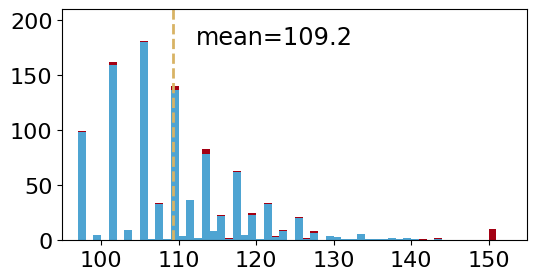

In [35]:
%matplotlib inline
fig, ax = plot_hist(results_cascade_match[0], results_cascade_match[1], xlim=(95, 155), ylim=210, bin_width=1, filename="cascade_match_searcher.pdf")

In [36]:
results_cascade_match_padded = evaluate(
    attack_expt_closure(
        searcher=simple_cascade_match_searcher,
        secret_size=32,
        noise_size=MATCH_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=CASCADE_MAX_QUERIES,
        block_pad_size=CASCADE_PAD_SIZE,
    ),
    n=NUM_EVALS,
    salt=b"cascade_match_searcher_padded",
    filename="cascade_match_searcher_padded.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [37]:
results_cascade_match_padded = load_results("cascade_match_searcher_padded.pickle")
analyze_results(results_cascade_match_padded, print_failures=False)

n: 1000, #successes: 962, max #queries: 150, max query length: 9896
stats on #queries:  {'min': 97, 'max': 150, 'mean': 109.524, 'stdev': 9.837082504085863}
stats on #queries in successful experiments:  {'min': 97, 'max': 146, 'mean': 108.72453222453223, 'stdev': 8.260332415368284}


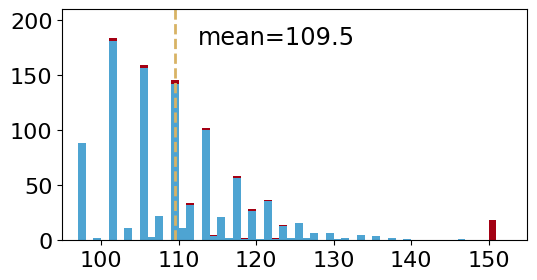

In [38]:
%matplotlib inline
fig, ax = plot_hist(results_cascade_match_padded[0], results_cascade_match_padded[1], xlim=(95, 155), ylim=210, bin_width=1, filename="cascade_match_searcher_padded.pdf")

#### collision

In [39]:
crime_cascade_coll_model = CRIMECascadeModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(),
        dict_1=SimpleDictionaryDedup(fine_grained=False),
        dict_2=SimpleDictionaryDedup(fine_grained=False),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder 0>"),
        CollisionAmplify(
            max_len=2700,
            instance=zlib_inst_set_double,
            auto_expand=True,
            no_dict=False,
            nop_gadget=None,
        ),
    ],
    placeholder=[2 * i + 1 for i in range(NUM_PLACEHOLDERS)],
    match_builder=deflate_match_builder_default,
    do_validity_check=True,
    test_oracle=ValidityCheckOracle(
        template=[b"secret=", Placeholder.SECRET, b"&query=", Placeholder.QUERY],
        compress=ZlibMiniCompressor(6).compress,
    ),
    thresholds=None,
    max_retry=1,
    strict=False,
    collect_stats=True,
)

for i in range(1, NUM_PLACEHOLDERS):
    crime_cascade_coll_model.gadgets += [
        PlaceholderGadget(f"<match_placeholder {i}>"),
        CollisionAmplify(
            max_len=2700,
            instance=zlib_inst_set_double,
            auto_expand=True,
            no_dict=True,
            nop_gadget=None,
            mirroring_gadget=crime_cascade_coll_model.gadgets[2],
        ),
    ]

In [40]:
crime_cascade_coll_model.stats = None
# determine thresholds empirically
threshold_rng = Random(ATTACK_RNG_SEED + b"cascade_coll/threshold")
for _ in range(100):
    fake_updates = [
        [f"123456{i * 6 + j:03}".encode() for j in range(6)]
        for i in range(NUM_PLACEHOLDERS)
    ]
    crime_cascade_coll_model(updates=fake_updates, rng=threshold_rng, recompile=True)
assert crime_cascade_coll_model.stats is not None
medians = [median(stat_i) for stat_i in crime_cascade_coll_model.stats] + [0]
thresholds_coll = [x + COLL_NOISE_SIZE + 20 for x in medians[:-1]]
thresholds_coll

[-2425.0, -2015.0, -1618.0, -1217.0, -815.0, -386.0]

In [41]:
# do not perform validity checks
crime_cascade_coll_model.do_validity_check = False
crime_cascade_coll_model.stats = None

simple_cascade_coll_searcher = SimpleCascadeSearcher(
    model=crime_cascade_coll_model,
    oracle=None,
    max_queries=None,
    thresholds=thresholds_coll,
    max_cands=None,
    max_cands_per_slot=6,
    ormatch_comp_len=13,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_baseline=True,
)
results_cascade_coll = evaluate(
    attack_expt_closure(
        searcher=simple_cascade_coll_searcher,
        secret_size=32,
        noise_size=CASCADE_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=CASCADE_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"cascade_coll_searcher",
    filename="cascade_coll_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [42]:
results_cascade_coll = load_results("cascade_coll_searcher.pickle")
analyze_results(results_cascade_coll, print_failures=False)

n: 1000, #successes: 934, max #queries: 150, max query length: 17265
stats on #queries:  {'min': 97, 'max': 150, 'mean': 119.941, 'stdev': 11.935743838612698}
stats on #queries in successful experiments:  {'min': 97, 'max': 149, 'mean': 119.05567451820129, 'stdev': 10.937761415650604}


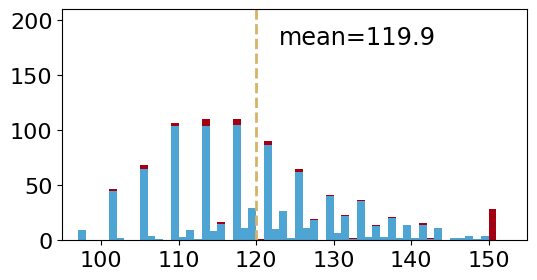

In [43]:
%matplotlib inline
fig, ax = plot_hist(results_cascade_coll[0], results_cascade_coll[1], xlim=(95, 155), ylim=210, bin_width=1, filename="cascade_coll_searcher.pdf")

In [44]:
results_cascade_coll_padded = evaluate(
    attack_expt_closure(
        searcher=simple_cascade_coll_searcher,
        secret_size=32,
        noise_size=CASCADE_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=CASCADE_MAX_QUERIES,
        block_pad_size=CASCADE_PAD_SIZE,
    ),
    n=NUM_EVALS,
    salt=b"cascade_coll_searcher_padded",
    filename="cascade_coll_searcher_padded.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [45]:
results_cascade_coll_padded = load_results("cascade_coll_searcher_padded.pickle")
analyze_results(results_cascade_coll_padded, print_failures=False)

n: 1000, #successes: 936, max #queries: 150, max query length: 17265
stats on #queries:  {'min': 97, 'max': 150, 'mean': 121.343, 'stdev': 11.863392899634198}
stats on #queries in successful experiments:  {'min': 97, 'max': 150, 'mean': 120.41132478632478, 'stdev': 10.90202551740279}


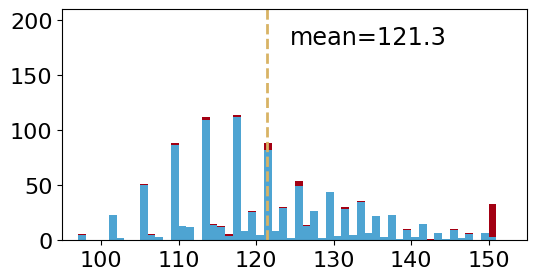

In [46]:
%matplotlib inline
fig, ax = plot_hist(results_cascade_coll_padded[0], results_cascade_coll_padded[1], xlim=(95, 155), ylim=210, bin_width=1, filename="cascade_coll_searcher_padded.pdf")

## Comparison with rupture

In [47]:
SAMPLESIZE = 100
CONF_THRES = 0.4
RUPTURE_NOISE_SIZE = 10
RUPTURE_MAX_QUERIES = 3000
RUPTURE_NUM_PLACEHOLDERS = 8

### Rupture (Divide and conquer)

In [48]:
rupture_parallel_searcher = RuptureSearcher(
    method=Target.DIVIDE_CONQUER, samplesize=SAMPLESIZE, confidence_threshold=CONF_THRES
)
results_rupture_parallel = evaluate(
    attack_expt_closure(
        searcher=rupture_parallel_searcher,
        secret_size=1,
        secret_charset=utils.HEX_BYTES,
        noise_size=RUPTURE_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=RUPTURE_MAX_QUERIES,
    ),
    n=NUM_EVALS,
    salt=b"rupture_parallel_searcher",
    filename=f"rupture_parallel_searcher_{SAMPLESIZE}_{CONF_THRES}.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [49]:
results_rupture_parallel = load_results(
    f"rupture_parallel_searcher_{SAMPLESIZE}_{CONF_THRES}.pickle"
)
analyze_results(results_rupture_parallel, print_failures=False)

n: 1000, #successes: 222, max #queries: 3000, max query length: 97
stats on #queries:  {'min': 800, 'max': 3000, 'mean': 1377, 'stdev': 748.5929410510037}
stats on #queries in successful experiments:  {'min': 800, 'max': 2600, 'mean': 1021.6216216216217, 'stdev': 352.2148165487271}


### Batch searcher

In [50]:
rupture_slide_match_model = CRIMESlideModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(),
        dict_1=SimpleDictionaryDedup(fine_grained=False),
        dict_2=SimpleDictionaryDedup(fine_grained=False),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(180, k=None, double=True),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)
rupture_batch_match_searcher = SimpleBatchSearcher(
    model=rupture_slide_match_model,
    oracle=None,
    max_queries=None,
    threshold=25,
    max_cands=None,
    ormatch_comp_len=13,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_history=False,
)

In [51]:
results_rupture_batch_match = evaluate(
    attack_expt_closure(
        searcher=rupture_batch_match_searcher,
        secret_size=1,
        secret_charset=utils.HEX_BYTES,
        noise_size=RUPTURE_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=RUPTURE_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=1000,
    salt=b"rupture_batch_match_searcher",
    filename="rupture_batch_match_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [52]:
results_rupture_batch_match = load_results("rupture_batch_match_searcher.pickle")
analyze_results(results_rupture_batch_match, print_failures=False)

n: 1000, #successes: 991, max #queries: 19, max query length: 615
stats on #queries:  {'min': 4, 'max': 19, 'mean': 5.6, 'stdev': 1.7195804595763924}
stats on #queries in successful experiments:  {'min': 4, 'max': 19, 'mean': 5.592330978809284, 'stdev': 1.6863389654823226}


### Cascade searcher

In [53]:
rupture_cascade_match_model = CRIMECascadeModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[6],
        filler=filler.SimpleFiller(),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
    ],
    placeholder=[2 * i + 1 for i in range(RUPTURE_NUM_PLACEHOLDERS)],
    match_builder=deflate_match_builder_default,
    do_validity_check=True,
    test_oracle=ValidityCheckOracle(
        template=[b"secret=", Placeholder.SECRET, b"&query=", Placeholder.QUERY],
        compress=ZlibMiniCompressor(6).compress,
    ),
    thresholds=None,
    max_retry=1,
    strict=False,
    collect_stats=True,
)

for i in range(RUPTURE_NUM_PLACEHOLDERS):
    rupture_cascade_match_model.gadgets += [
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(120 + 10 * i, k=None, double=True),
    ]

In [54]:
rupture_cascade_match_model.stats = None
# determine thresholds empirically
threshold_rng = Random(ATTACK_RNG_SEED + b"rupture_cascade_match/threshold")
for _ in range(100):
    fake_updates = [[f"123456{i:03}".encode()] for i in range(8)]
    rupture_cascade_match_model(updates=fake_updates, rng=threshold_rng, recompile=True)
assert rupture_cascade_match_model.stats is not None
medians = [median(stat_i) for stat_i in rupture_cascade_match_model.stats] + [0]
rupture_thresholds_match = [(x1 + x2) / 2 for x1, x2 in zip(medians, medians[1:])]
rupture_thresholds_match

[359.0, 306.5, 256.0, 206.5, 157.75, 107.75, 60.5, 19.5]

In [55]:
rupture_cascade_match_model.do_validity_check = False
rupture_cascade_match_model.stats = None

rupture_cascade_match_searcher = SimpleCascadeSearcher(
    model=rupture_cascade_match_model,
    oracle=None,
    max_queries=None,
    thresholds=rupture_thresholds_match,
    max_cands=None,
    max_cands_per_slot=None,
    ormatch_comp_len=13,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_baseline=False,
)

results_rupture_cascade_match = evaluate(
    attack_expt_closure(
        searcher=rupture_cascade_match_searcher,
        secret_size=1,
        secret_charset=utils.HEX_BYTES,
        noise_size=RUPTURE_NOISE_SIZE,
        compress=ZlibMiniCompressor(6).compress,
        max_queries=RUPTURE_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"rupture_cascade_match_searcher",
    filename="rupture_cascade_match_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [56]:
results_rupture_cascade_match = load_results("rupture_cascade_match_searcher.pickle")
analyze_results(results_rupture_cascade_match, print_failures=False)

n: 1000, #successes: 962, max #queries: 4, max query length: 3624
stats on #queries:  {'min': 2, 'max': 4, 'mean': 2.006, 'stdev': 0.10943480239839598}
stats on #queries in successful experiments:  {'min': 2, 'max': 4, 'mean': 2.006237006237006, 'stdev': 0.11157083843995971}


### Save stats

In [57]:
with open(Path(RESULTS_DIR) / "rupture_comparison.csv", "w") as f:
    f.write("Method,Success rate,Mean num. queries,Max. query length\n")
    data = (("Rupture", results_rupture_parallel), ("Batch", results_rupture_batch_match), ("Cascade", results_rupture_cascade_match))
    for name, results in data:
        f.write(f"{name},{sum(results[0])}/{len(results[0])},{mean(results[1])},{max(results[2])}B\n")

## Deflate_fast

In [58]:
FAST_MAX_CANDS = 15  # max_chain=32

### Batch match search

In [59]:
FAST_BATCH_MAX_QUERIES = 400
FAST_MATCH_NOISE_SIZE = 50
FAST_BATCH_PAD_SIZE = 16

In [60]:
fast_crime_slide_match_model = CRIMESlideModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[3],
        filler=filler.SimpleFiller(b"-" * 100),
        dict_1=SimpleDictionaryDedup(fine_grained=False),
        dict_2=SimpleDictionaryDedup(fine_grained=False),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder>"),
        MatchChainAutomatedAmplify(700, k=None, double=True),
    ],
    placeholder=1,
    match_builder=deflate_match_builder_default,
)
batch_match_searcher = SimpleBatchSearcher(
    model=fast_crime_slide_match_model,
    oracle=None,
    max_queries=None,
    threshold=110,
    max_cands=FAST_MAX_CANDS,
    ormatch_comp_len=10,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_history=False,
)

In [61]:
results_fast_batch_match = evaluate(
    attack_expt_closure(
        searcher=batch_match_searcher,
        secret_size=32,
        noise_size=FAST_MATCH_NOISE_SIZE,
        compress=ZlibMiniCompressor(3).compress,
        max_queries=FAST_BATCH_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"fast_batch_match_searcher",
    filename="fast_batch_match_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [62]:
results_fast_batch_match = load_results("fast_batch_match_searcher.pickle")
analyze_results(results_fast_batch_match, print_failures=False)

n: 1000, #successes: 991, max #queries: 400, max query length: 2415
stats on #queries:  {'min': 239, 'max': 400, 'mean': 296.605, 'stdev': 28.182747244408986}
stats on #queries in successful experiments:  {'min': 239, 'max': 397, 'mean': 295.765893037336, 'stdev': 26.727802782882634}


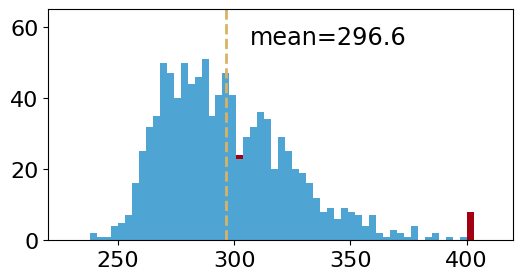

In [63]:
%matplotlib inline
fig, ax = plot_hist(results_fast_batch_match[0], results_fast_batch_match[1], xlim=(220, 420), ylim=65, bin_width=3, filename="fast_batch_match_searcher.pdf")

In [64]:
results_fast_batch_match_padded = evaluate(
    attack_expt_closure(
        searcher=batch_match_searcher,
        secret_size=32,
        noise_size=FAST_MATCH_NOISE_SIZE,
        compress=ZlibMiniCompressor(3).compress,
        max_queries=FAST_BATCH_MAX_QUERIES,
        block_pad_size=FAST_BATCH_PAD_SIZE,
    ),
    n=NUM_EVALS,
    salt=b"fast_batch_match_searcher_padded",
    filename="fast_batch_match_searcher_padded.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [65]:
results_fast_batch_match_padded = load_results("fast_batch_match_searcher_padded.pickle")
analyze_results(results_fast_batch_match_padded, print_failures=False)

n: 1000, #successes: 997, max #queries: 400, max query length: 2415
stats on #queries:  {'min': 244, 'max': 400, 'mean': 296.118, 'stdev': 26.608872732757924}
stats on #queries in successful experiments:  {'min': 244, 'max': 400, 'mean': 295.90170511534603, 'stdev': 26.237109420518888}


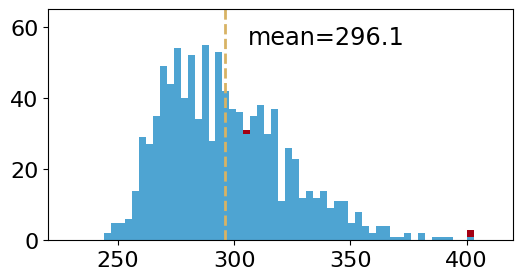

In [66]:
%matplotlib inline
fig, ax = plot_hist(results_fast_batch_match_padded[0], results_fast_batch_match_padded[1], xlim=(220, 420), ylim=65, bin_width=3, filename="fast_batch_match_searcher_padded.pdf")

### Cascade coll search

In [67]:
FAST_NUM_PLACEHOLDERS = 4
FAST_COLL_NOISE_SIZE = 100
FAST_CASCADE_MAX_QUERIES = 200
FAST_CASCADE_PAD_SIZE = 16

In [68]:
fast_crime_cascade_coll_model = CRIMECascadeModel(
    machine=automata.DeflateAutomaton(
        charset=utils.ALPHANUMERIC_BYTES,
        params=params.ZLIB_PARAMS[3],
        filler=filler.SimpleFiller(),
        dict_1=SimpleDictionaryDedup(fine_grained=False),
        dict_2=SimpleDictionaryDedup(fine_grained=False),
    ),
    gadgets=[
        DefaultAlign(b"@", 10),
        PlaceholderGadget("<match_placeholder 0>"),
        CollisionAmplify(
            max_len=5500,
            instance=zlib_inst_set_single,
            auto_expand=True,
            no_dict=False,
            nop_gadget=None,
        ),
    ],
    placeholder=[2 * i + 1 for i in range(FAST_NUM_PLACEHOLDERS)],
    match_builder=deflate_match_builder_default,
    do_validity_check=True,
    test_oracle=ValidityCheckOracle(
        template=[b"secret=", Placeholder.SECRET, b"&query=", Placeholder.QUERY],
        compress=ZlibMiniCompressor(3).compress,
    ),
    thresholds=None,
    max_retry=1,
    strict=False,
    collect_stats=True,
)

for i in range(1, FAST_NUM_PLACEHOLDERS):
    fast_crime_cascade_coll_model.gadgets += [
        PlaceholderGadget(f"<match_placeholder {i}>"),
        CollisionAmplify(
            max_len=5500,
            instance=zlib_inst_set_single,
            auto_expand=True,
            no_dict=True,
            nop_gadget=None,
            mirroring_gadget=fast_crime_cascade_coll_model.gadgets[2],
        ),
    ]

In [69]:
fast_crime_cascade_coll_model.stats = None
# determine thresholds empirically
fast_threshold_rng = Random(ATTACK_RNG_SEED + b"fast_cascade_coll/threshold")
for _ in range(100):
    fake_updates = [[f"123456{i:03}".encode()] for i in range(FAST_NUM_PLACEHOLDERS)]
    fast_crime_cascade_coll_model(
        updates=fake_updates, rng=fast_threshold_rng, recompile=True
    )
assert fast_crime_cascade_coll_model.stats is not None
medians = [median(stat_i) for stat_i in fast_crime_cascade_coll_model.stats] + [0]
fast_thresholds_coll = [(x1 + x2) / 2 for x1, x2 in zip(medians, medians[1:])]
fast_thresholds_coll

[-3782.25, -2741.75, -1678.0, -571.5]

In [70]:
# do not perform validity checks
fast_crime_cascade_coll_model.do_validity_check = False
fast_crime_cascade_coll_model.stats = None

fast_cascade_coll_searcher = SimpleCascadeSearcher(
    model=fast_crime_cascade_coll_model,
    oracle=None,
    max_queries=None,
    thresholds=fast_thresholds_coll,
    max_cands=FAST_MAX_CANDS,
    max_cands_per_slot=None,
    ormatch_comp_len=10,
    repeat=1,
    recompile=False,
    flush_backtrack=True,
    flush_repeat=False,
    strict=True,
    truncate_target=-9,
    use_baseline=True,
)
results_fast_cascade_coll = evaluate(
    attack_expt_closure(
        searcher=fast_cascade_coll_searcher,
        secret_size=32,
        noise_size=FAST_COLL_NOISE_SIZE,
        compress=ZlibMiniCompressor(3).compress,
        max_queries=FAST_CASCADE_MAX_QUERIES,
        block_pad_size=0,
    ),
    n=NUM_EVALS,
    salt=b"fast_cascade_coll_searcher",
    filename="fast_cascade_coll_searcher.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [71]:
results_fast_cascade_coll = load_results("fast_cascade_coll_searcher.pickle")
analyze_results(results_fast_cascade_coll, print_failures=False)

n: 1000, #successes: 973, max #queries: 200, max query length: 21372
stats on #queries:  {'min': 115, 'max': 200, 'mean': 143.034, 'stdev': 12.109313749320375}
stats on #queries in successful experiments:  {'min': 115, 'max': 178, 'mean': 141.99486125385405, 'stdev': 9.420938848780311}


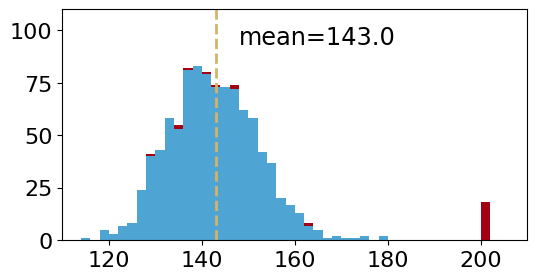

In [72]:
%matplotlib inline
fig, ax = plot_hist(results_fast_cascade_coll[0], results_fast_cascade_coll[1], xlim=(110, 210), ylim=110, bin_width=2, filename="fast_cascade_coll_searcher.pdf")

In [73]:
results_fast_cascade_coll_padded = evaluate(
    attack_expt_closure(
        searcher=fast_cascade_coll_searcher,
        secret_size=32,
        noise_size=FAST_COLL_NOISE_SIZE,
        compress=ZlibMiniCompressor(3).compress,
        max_queries=FAST_CASCADE_MAX_QUERIES,
        block_pad_size=FAST_CASCADE_PAD_SIZE,
    ),
    n=NUM_EVALS,
    salt=b"fast_cascade_coll_searcher_padded",
    filename="fast_cascade_coll_searcher_padded.pickle",
)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [74]:
results_fast_cascade_coll_padded = load_results("fast_cascade_coll_searcher_padded.pickle")
analyze_results(results_fast_cascade_coll_padded, print_failures=False)

n: 1000, #successes: 981, max #queries: 200, max query length: 21372
stats on #queries:  {'min': 117, 'max': 200, 'mean': 142.523, 'stdev': 11.572614069275636}
stats on #queries in successful experiments:  {'min': 117, 'max': 181, 'mean': 141.73598369011214, 'stdev': 9.515648753486738}


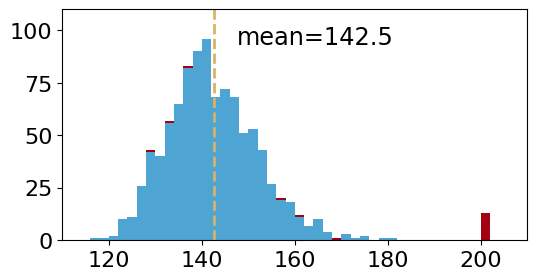

In [75]:
%matplotlib inline
fig, ax = plot_hist(results_fast_cascade_coll_padded[0], results_fast_cascade_coll_padded[1], xlim=(110, 210), ylim=110, bin_width=2, filename="fast_cascade_coll_searcher_padded.pdf")